Sel 1 — Mount Google Drive & Install Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn opencv-python lime tqdm -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Sel 2 — Import Library

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

from lime import lime_image
from skimage.segmentation import mark_boundaries

Sel 3 — Konfigurasi Path & Parameter

In [ ]:
BASE_DIR   = Path("/content/drive/MyDrive/Pothole_Classification_Project")
TRAIN_DIR  = BASE_DIR / "dataset/2_processed/train"
TEST_DIR   = BASE_DIR / "dataset/2_processed/test"
MODEL_DIR  = BASE_DIR / "saved_models"
OUTPUT_DIR = BASE_DIR / "outputs"

CLASSES    = ["berlubang", "mulus"]
IMG_SIZE   = (224, 224)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi siap.")

✅ Konfigurasi siap.


Sel 4 — Bangun Feature Extractor (MobileNetV2 Tanpa Head)

In [ ]:
print("🔧 Membangun feature extractor dari MobileNetV2...\n")

base_model = MobileNetV2(
    input_shape = (*IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet"
)
base_model.trainable = False

feature_extractor = Model(
    inputs  = base_model.input,
    outputs = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
)

print(f"✅ Feature extractor siap.")
print(f"   Output vektor : {feature_extractor.output_shape[1]} dimensi per gambar")

🔧 Membangun feature extractor dari MobileNetV2...

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Feature extractor siap.
   Output vektor : 1280 dimensi per gambar


Sel 5 — Fungsi Load & Preprocess Gambar

In [ ]:
def load_and_preprocess(img_path, size=IMG_SIZE):
    """
    Baca gambar RGB → resize ke 224x224 → preprocess standar MobileNetV2.
    Tetap RGB karena MobileNetV2 sudah expect 3 channel
    dan fitur yang lebih kaya menguntungkan SVM.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, size, interpolation=cv2.INTER_AREA)
    img_pre     = preprocess_input(img_resized.astype(np.float32))
    return img_pre

Sel 6 — Ekstraksi Fitur CNN Train Set

In [ ]:
print("⚙️  Mengekstrak fitur CNN dari Train Set...\n")

X_train_cnn, y_train = [], []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    batch = []

    for path in tqdm(paths, desc=f"[{cls}]"):
        img = load_and_preprocess(path)
        if img is not None:
            batch.append(img)
            y_train.append(label_idx)

    batch_array = np.array(batch)
    features    = feature_extractor.predict(batch_array, batch_size=32, verbose=0)
    X_train_cnn.extend(features)

X_train_cnn = np.array(X_train_cnn)
y_train     = np.array(y_train)

print(f"\n✅ Train set siap.")
print(f"   Jumlah sampel : {X_train_cnn.shape[0]}")
print(f"   Panjang vektor: {X_train_cnn.shape[1]}")

⚙️  Mengekstrak fitur CNN dari Train Set...



[mulus]: 100%|██████████| 1540/1540 [00:33<00:00, 45.97it/s] 



✅ Train set siap.
   Jumlah sampel : 3080
   Panjang vektor: 1280


Sel 7 — Ekstraksi Fitur CNN Test Set

In [ ]:
print("⚙️  Mengekstrak fitur CNN dari Test Set...\n")

X_test_cnn, y_test  = [], []
test_images_raw     = []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TEST_DIR / cls).glob("*.jpg"))
    batch = []

    for path in tqdm(paths, desc=f"[{cls}]"):
        img = cv2.imread(str(path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_res = cv2.resize(img_rgb, IMG_SIZE)
        test_images_raw.append(img_res)

        img_pre = load_and_preprocess(path)
        if img_pre is not None:
            batch.append(img_pre)
            y_test.append(label_idx)

    batch_array = np.array(batch)
    features    = feature_extractor.predict(batch_array, batch_size=32, verbose=0)
    X_test_cnn.extend(features)

X_test_cnn      = np.array(X_test_cnn)
y_test          = np.array(y_test)
test_images_raw = np.array(test_images_raw)

print(f"\n✅ Test set siap.")
print(f"   Jumlah sampel : {X_test_cnn.shape[0]}")

⚙️  Mengekstrak fitur CNN dari Test Set...



[mulus]: 100%|██████████| 35/35 [00:05<00:00,  6.39it/s]



✅ Test set siap.
   Jumlah sampel : 70


Sel 8 — Normalisasi Fitur

In [ ]:
scaler      = StandardScaler()
X_train_cnn = scaler.fit_transform(X_train_cnn)
X_test_cnn  = scaler.transform(X_test_cnn)

print("✅ Fitur dinormalisasi dengan StandardScaler.")

✅ Fitur dinormalisasi dengan StandardScaler.


Sel 9 — Hyperparameter Tuning + Training SVM

In [ ]:
# print("🔍 Memulai Hyperparameter Tuning (GridSearchCV)...\n")

# param_grid = {
#     "C"      : [1, 10],
#     "kernel" : ["linear", "rbf"],
#     "gamma"  : ["scale"]
# }

# grid_search = GridSearchCV(
#     estimator  = SVC(probability=True, random_state=42),
#     param_grid = param_grid,
#     cv         = 5,
#     scoring    = "accuracy",
#     n_jobs     = -1,
#     verbose    = 2
# )

# grid_search.fit(X_train_cnn, y_train)

# print("\n✅ Tuning selesai!")
# print(f"   Best Params   : {grid_search.best_params_}")
# print(f"   Best CV Score : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# # Fitting 5 folds for each of 4 candidates, totalling 20 fits

# # ✅ Tuning selesai!
# # Best Params   : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
# # Best CV Score : 0.9587 (95.87%)

# svm_model = grid_search.best_estimator_

Sel 10 — Training SVM (Parameter Terbaik)

In [ ]:
print("🏋️  Melatih SVM dengan parameter terbaik...\n")

svm_model = SVC(
    C            = 10,
    kernel       = "rbf",
    gamma        = "scale",
    probability  = True,
    random_state = 42
)

svm_model.fit(X_train_cnn, y_train)
print("✅ Training selesai!")

🏋️  Melatih SVM dengan parameter terbaik...

✅ Training selesai!


Sel 11 — Evaluasi Model

In [ ]:
y_pred = svm_model.predict(X_test_cnn)

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec  = recall_score   (y_test, y_pred, average="weighted")
f1   = f1_score       (y_test, y_pred, average="weighted")

print("=" * 50)
print("     HASIL EVALUASI — Hybrid CNN + SVM")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 50)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

     HASIL EVALUASI — Hybrid CNN + SVM
  Accuracy  : 0.9714  (97.14%)
  Precision : 0.9730
  Recall    : 0.9714
  F1-Score  : 0.9714

Classification Report:

              precision    recall  f1-score   support

   berlubang       0.95      1.00      0.97        35
       mulus       1.00      0.94      0.97        35

    accuracy                           0.97        70
   macro avg       0.97      0.97      0.97        70
weighted avg       0.97      0.97      0.97        70



Sel 12 — Confusion Matrix

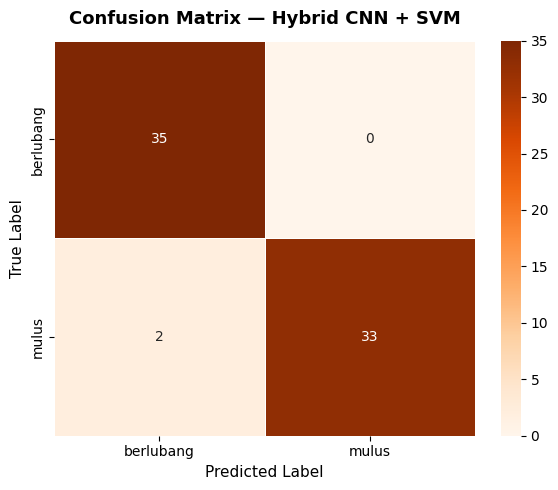

✅ Confusion matrix disimpan ke outputs/


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — Hybrid CNN + SVM", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_hybrid_cnn_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix disimpan ke outputs/")

Sel 13 — Cross Validation Score

🔍 Menghitung Cross Validation Score...

  CV Scores per fold : ['0.9724', '0.9870', '0.9838', '0.9821', '0.9870']
  Mean CV Accuracy   : 0.9825 (98.25%)
  Std CV Accuracy    : 0.0054
  Test Accuracy      : 0.9714 (97.14%)
  Selisih CV vs Test : 0.0110


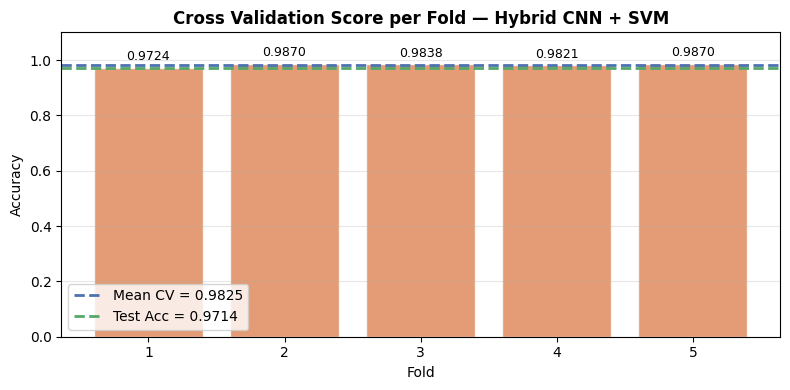

✅ CV scores disimpan ke outputs/


In [ ]:
print("🔍 Menghitung Cross Validation Score...\n")

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=42),
    X_train_cnn, y_train,
    cv      = cv,
    scoring = "accuracy",
    n_jobs  = -1
)

print(f"  CV Scores per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean CV Accuracy   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std CV Accuracy    : {cv_scores.std():.4f}")
print(f"  Test Accuracy      : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Selisih CV vs Test : {abs(cv_scores.mean() - acc):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 6), cv_scores, color="#DD8452", alpha=0.8, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#4C72B0", linestyle="--",
           linewidth=2, label=f"Mean CV = {cv_scores.mean():.4f}")
ax.axhline(acc, color="#55A868", linestyle="--",
           linewidth=2, label=f"Test Acc = {acc:.4f}")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("Cross Validation Score per Fold — Hybrid CNN + SVM",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_scores_hybrid_cnn_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ CV scores disimpan ke outputs/")

Sel 14 — Diagnosis Otomatis

In [ ]:
print("\n" + "=" * 50)
print("    DIAGNOSIS MODEL — Hybrid CNN + SVM")
print("=" * 50)

cv_test_gap = abs(cv_scores.mean() - acc)

print(f"\n  Mean CV Accuracy   : {cv_scores.mean():.4f}")
print(f"  Test Accuracy      : {acc:.4f}")
print(f"  Std CV             : {cv_scores.std():.4f}")
print(f"  Gap CV vs Test     : {cv_test_gap:.4f}")

print("\n  📋 Kesimpulan:")

if cv_scores.mean() < 0.7 and acc < 0.7:
    print("  ⚠️  UNDERFITTING — Akurasi CV dan Test sama-sama rendah.")
    print("      Saran: coba arsitektur CNN yang lebih dalam.")

elif acc - cv_scores.mean() > 0.1:
    print("  ⚠️  OVERFITTING — Test accuracy jauh lebih tinggi dari CV.")
    print("      Saran: tambah regularisasi pada SVM.")

elif cv_scores.mean() - acc > 0.1:
    print("  ⚠️  DISTRIBUSI TIDAK KONSISTEN — CV jauh lebih tinggi dari Test.")
    print("      Kemungkinan distribusi train dan test tidak seragam.")

elif cv_scores.std() > 0.05:
    print("  ⚠️  VARIANCE TINGGI — Performa tidak stabil antar fold.")
    print("      Model sensitif terhadap pembagian data.")

else:
    print("  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.")
    print(f"     Performa stabil dengan std CV = {cv_scores.std():.4f}")
    print(f"     Gap CV vs Test = {cv_test_gap:.4f} (dalam batas wajar)")

print("=" * 50)


    DIAGNOSIS MODEL — Hybrid CNN + SVM

  Mean CV Accuracy   : 0.9825
  Test Accuracy      : 0.9714
  Std CV             : 0.0054
  Gap CV vs Test     : 0.0110

  📋 Kesimpulan:
  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.
     Performa stabil dengan std CV = 0.0054
     Gap CV vs Test = 0.0110 (dalam batas wajar)


Sel 15 — LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

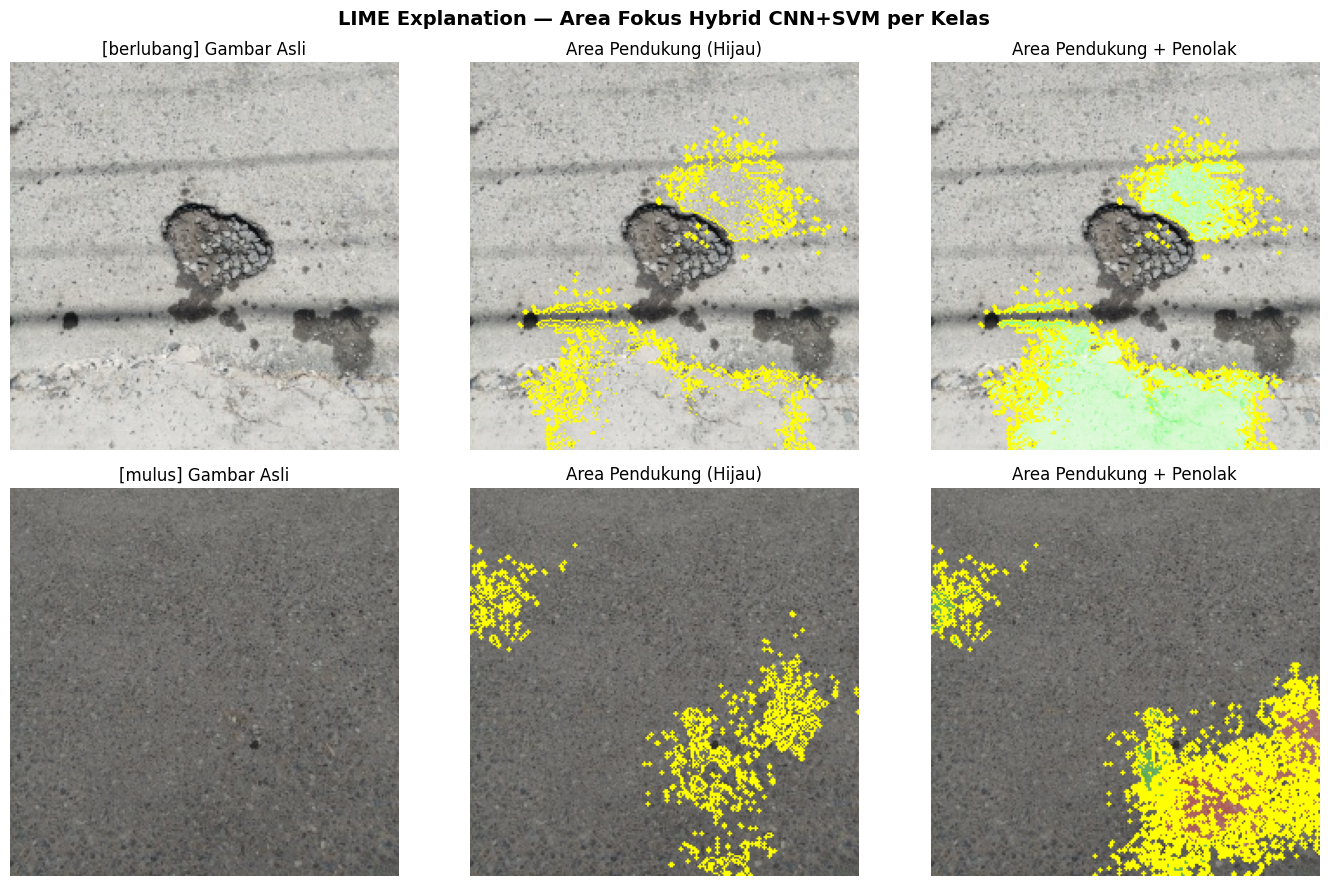

✅ Visualisasi LIME disimpan ke outputs/


In [ ]:
def predict_fn_hybrid(images):
    batch = []
    for img in images:
        img_gray    = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        img_resized = cv2.resize(img_gray, IMG_SIZE)
        img_3ch     = cv2.merge([img_resized, img_resized, img_resized])
        img_pre     = preprocess_input(img_3ch.astype(np.float32))
        batch.append(img_pre)

    batch_array  = np.array(batch)
    features     = feature_extractor.predict(batch_array, batch_size=32, verbose=0)
    features_sc  = scaler.transform(features)
    return svm_model.predict_proba(features_sc)

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("LIME Explanation — Area Fokus Hybrid CNN+SVM per Kelas",
             fontsize=14, fontweight="bold")

sample_indices = {
    "berlubang": np.where(y_test == 0)[0][0],
    "mulus"    : np.where(y_test == 1)[0][0]
}

for row, (cls, idx) in enumerate(sample_indices.items()):
    img_display = test_images_raw[idx]

    explanation = explainer.explain_instance(
        img_display.astype(np.double),
        predict_fn_hybrid,
        top_labels  = 2,
        hide_color  = 0,
        num_samples = 1000
    )

    label_idx = 0 if cls == "berlubang" else 1

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"[{cls}] Gambar Asli")
    axes[row, 0].axis("off")

    temp_pos, mask_pos = explanation.get_image_and_mask(
        label_idx, positive_only=True, num_features=5, hide_rest=False
    )
    axes[row, 1].imshow(mark_boundaries(temp_pos.astype(np.uint8), mask_pos))
    axes[row, 1].set_title("Area Pendukung (Hijau)")
    axes[row, 1].axis("off")

    temp_neg, mask_neg = explanation.get_image_and_mask(
        label_idx, positive_only=False, num_features=5, hide_rest=False
    )
    axes[row, 2].imshow(mark_boundaries(temp_neg.astype(np.uint8), mask_neg))
    axes[row, 2].set_title("Area Pendukung + Penolak")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lime_hybrid_cnn_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi LIME disimpan ke outputs/")

Sel 16 — Simpan Model

In [ ]:
joblib.dump(svm_model, MODEL_DIR / "svm_cnn_model.pkl")
joblib.dump(scaler,    MODEL_DIR / "scaler_cnn.pkl")
feature_extractor.save(MODEL_DIR / "mobilenet_feature_extractor.keras")

print("✅ Model tersimpan:")
print(f"   → {MODEL_DIR / 'svm_cnn_model.pkl'}")
print(f"   → {MODEL_DIR / 'scaler_cnn.pkl'}")
print(f"   → {MODEL_DIR / 'mobilenet_feature_extractor.keras'}")

✅ Model tersimpan:
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/svm_cnn_model.pkl
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/scaler_cnn.pkl
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_feature_extractor.keras
